In [1]:
import scipy.stats as stats
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import _syntax_score_helper_function as syn
from _helper_functions import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
syn2en2afflist=load_pickle_dict('F05-Syntax-Features/syn2en2afflist.pydict.pickle')
en2syn2afflist=load_pickle_dict('F05-Syntax-Features/en2syn2afflist.pydict.pickle')

In [3]:
fn='F05-Syntax-Features/6-real-and-imputed-motifs.pd.df.pickle'
sigDF=pd.read_pickle(fn).reset_index()

phrases=[]
for phrasekey in sigDF['phrase-key']:
    phrasekey=phrasekey.split('=')[-1]
    phrasekey=phrasekey.split('_')
    thisphrase=[]
    for i in phrasekey:
        try:
            i=int(i)
        except ValueError:
            pass
        thisphrase.append(i)
    phrases.append(tuple(thisphrase))
sigDF['phrase']=phrases
sigDF['num-inert-seqs']=sigDF['real-data'].apply(lambda tup: tup[2])
sigDF['num-total-seqs']=sigDF['real-data'].apply(lambda tup: tup[0]+tup[2])
sigDF['percent-func']=100*sigDF['num-active-ens']/sigDF['num-total-seqs']
sigDF['percent-inert']=100*sigDF['num-inert-seqs']/sigDF['num-total-seqs']
sigDF=sigDF.set_index('phrase',drop=False)
sigDF.sort_values('percent-func',ascending=False).head(10)


,phrase-key,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed,phrase,num-inert-seqs,percent-func,percent-inert
phrase,,,,,,,,,,,,
"(g, 21, e, 24, E)",ord_ori_spc=g_21_e_24_E,3.0,11.206427,"(63, 34, 7)",3.246130e-29,70,63.0,obs,"(g, 21, e, 24, E)",7,90.000000,10.000000
"(g, 13, e, 24, E)",ord_ori_spc=g_13_e_24_E,3.0,8.385350,"(108, 73, 21)",3.208155e-43,129,108.0,obs,"(g, 13, e, 24, E)",21,83.720930,16.279070
"(g, 15, E, 22, E)",ord_ori_spc=g_15_E_22_E,3.0,7.098879,"(107, 85, 25)",2.072536e-38,132,107.0,obs,"(g, 15, E, 22, E)",25,81.060606,18.939394
"(g, 33, e, 24, E)",ord_ori_spc=g_33_e_24_E,3.0,6.118849,"(47, 44, 12)",1.610690e-14,59,47.0,obs,"(g, 33, e, 24, E)",12,79.661017,20.338983
"(g, 28, e, 24, E)",ord_ori_spc=g_28_e_24_E,3.0,4.441899,"(39, 54, 10)",1.340001e-08,49,39.0,obs,"(g, 28, e, 24, E)",10,79.591837,20.408163
"(g, 36, g, 9, E)",ord_ori_spc=g_36_g_9_E,3.0,7.889255,"(162, 108, 42)",8.148688e-63,204,162.0,obs,"(g, 36, g, 9, E)",42,79.411765,20.588235
"(e, 24, E, 8, G)",ord_ori_spc=e_24_E_8_G,3.0,7.029848,"(105, 80, 29)",2.031084e-37,134,105.0,obs,"(e, 24, E, 8, G)",29,78.358209,21.641791
"(g, 15, E, 23, E)",ord_ori_spc=g_15_E_23_E,3.0,4.420427,"(80, 107, 25)",7.409182e-19,105,80.0,obs,"(g, 15, E, 23, E)",25,76.190476,23.809524
"(e, 21, e, 9, G)",ord_ori_spc=e_21_e_9_G,3.0,4.312363,"(81, 111, 26)",1.338174e-18,107,81.0,obs,"(e, 21, e, 9, G)",26,75.700935,24.299065


In [4]:
np.median(sigDF.loc[sigDF['phrase-length']==2,'percent-func'])

34.20121989016359

In [5]:
np.median(sigDF.loc[sigDF['phrase-length']==3,'percent-func'])

47.78472138765373

[Text(0, 0, '2mer active'),
 Text(1, 0, '2mer inert'),
 Text(2, 0, '3mer active'),
 Text(3, 0, '3mer inert')]

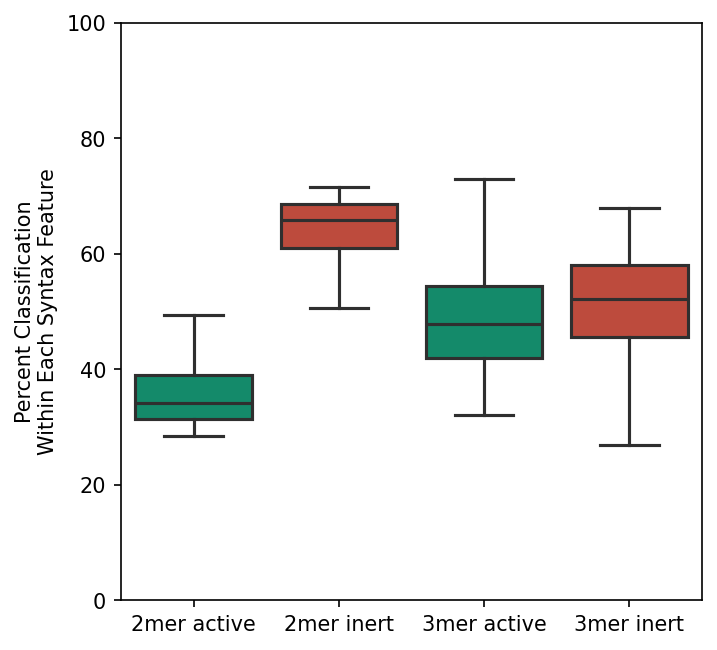

In [6]:

fig,ax=quickfig()
data=[sigDF.loc[sigDF['phrase-length']==2,col] for col in ['percent-func','percent-inert']]
data+=[sigDF.loc[sigDF['phrase-length']==3,col] for col in ['percent-func','percent-inert']]

sns.boxplot(data=data, palette=[cb['green'],cb['orangenature']],fliersize=0)
plt.ylim(0,100)
plt.ylabel('Percent Classification\nWithin Each Syntax Feature')
ax.set_xticklabels(['2mer active','2mer inert','3mer active','3mer inert'])


In [7]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
df=pd.read_pickle(fn).set_index('wt-enhancer-seq',drop=False)

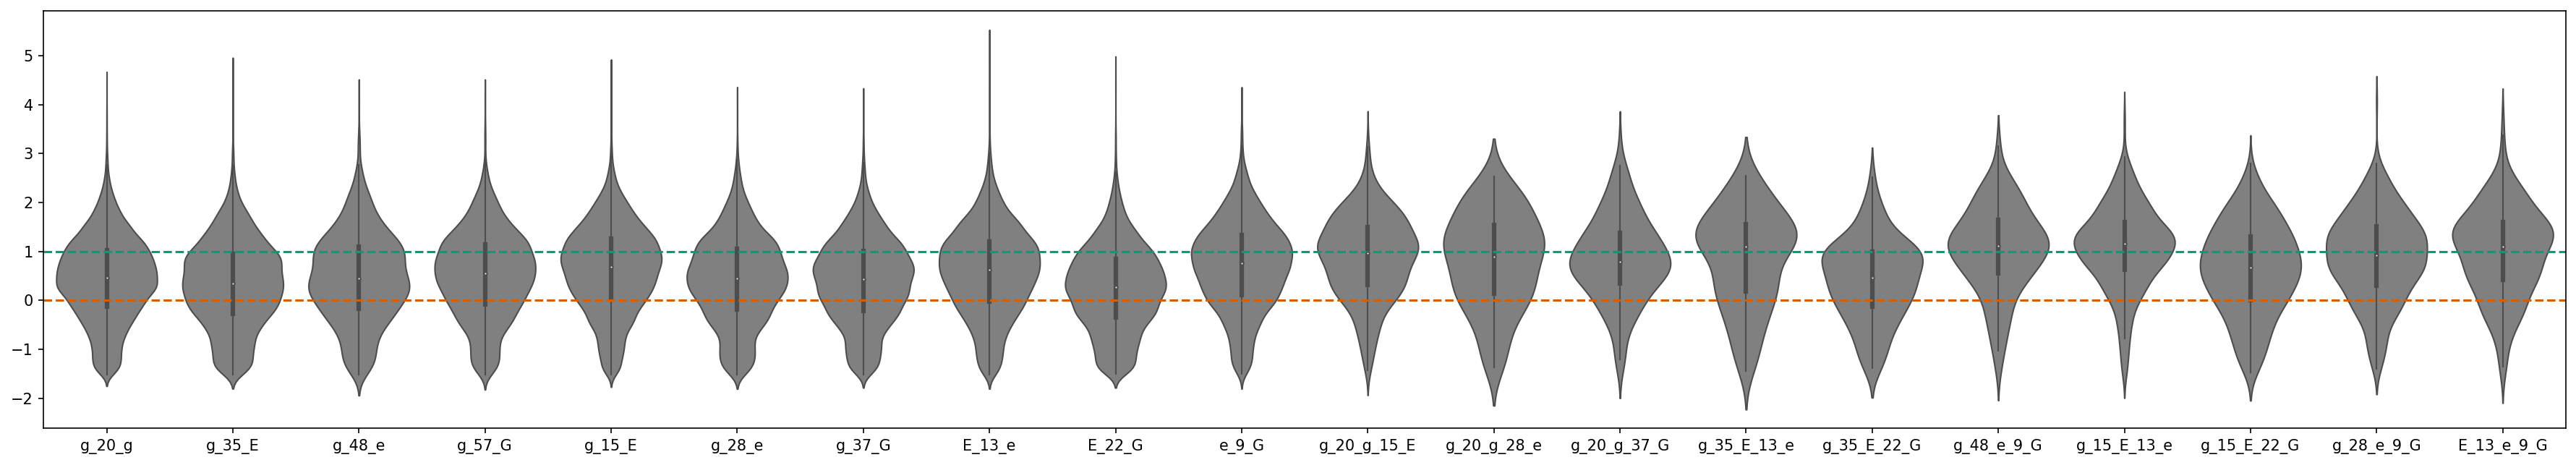

In [8]:
elementsToVisualize=[
'CCTATCTTCATCTGAAGCTCGTTATCTCTTTCGAAAAGGAAATTGCTCACTTCCGTTAAGATATTA', # ORL 25
]

for i,element in enumerate(elementsToVisualize):

    featlist=en2syn2afflist[element].keys()

    xlabs=[]
    data=[]
    for feat in featlist:
        enhancers=syn2en2afflist[feat].keys()
        enhancerActivities=df.loc[enhancers,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].tolist()
        data.append(enhancerActivities)
        xlabs.append('_'.join([str(i) for i in feat]))

    fig,ax=quickfig(30,5)
    # sns.stripplot(data=data,color='grey')
    sns.violinplot(data=data,color='grey',scale='width',linewidth=1)
    ax.set_xticklabels(xlabs)
    ax.axhline(0,ls='--',color=cb['red'])
    ax.axhline(1,ls='--',color=cb['green'])




('g', 15, 'E', 22, 'E')
off 10
on 75
('g', 36, 'g', 9, 'E')
off 19
on 125


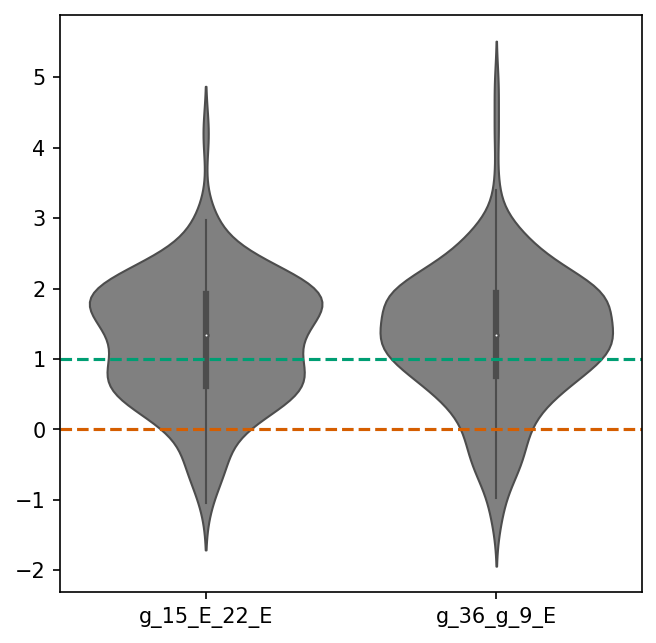

In [9]:
featlist=[('g',15,'E',22,'E'),('g',36,'g',9,'E')]

xlabs=[]
data=[]
for feat in featlist:
    enhancers=syn2en2afflist[feat].keys()
    enhancerActivities=df.loc[enhancers,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].tolist()
    data.append(enhancerActivities)
    xlabs.append('_'.join([str(i) for i in feat]))
    print(feat)
    print('off',len([i for i in enhancerActivities if i<0]))
    print('on',len([i for i in enhancerActivities if i>1]))

fig,ax=quickfig(5,5)

sns.violinplot(data=data,color='grey',scale='width',linewidth=1)
ax.set_xticklabels(xlabs)
ax.axhline(0,ls='--',color=cb['red'])
ax.axhline(1,ls='--',color=cb['green'])
plt.show()


